In [1]:
import pandas as pd 
df=pd.read_csv("TelcoCustomerChurn_Clean.csv")

In [2]:
# Définir x et y :

# Encoder la variable cible
df["ChurnLabel"] = df["ChurnLabel"].map({
    "No": 0,
    "Yes": 1
})

#definir x et y 
y = df["ChurnLabel"]
X = df.drop(columns=["ChurnLabel"])
print("Nombre de variables explicatives :", X.shape[1])
print("Nombre de clients :", X.shape[0])

Nombre de variables explicatives : 39
Nombre de clients : 7043


In [3]:
# Eviter fuite de données : 

data_leakage = [
    "ChurnScore",
    "ChurnCategory",
    "ChurnReason",
    "CustomerStatus",
    "SatisfactionScore"
]


X = X.drop(columns=data_leakage)

print("Nombre de variables après suppression :", X.shape[1])



Nombre de variables après suppression : 34


In [4]:
#séparation train/test 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (5634, 34)
X_test : (1409, 34)
y_train : (5634,)
y_test : (1409,)


In [5]:
# Étape 4 — Préparer les variables (Encoding / Standarisation ) 

# Séparation des variables numériques et catégorielles :
from sklearn.preprocessing import StandardScaler
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Variables numériques :", len(numeric_features))
print("Variables catégorielles :", len(categorical_features))



# Frequency Encoding des variables catégorielles

for col in categorical_features:
    # Calculer les fréquences uniquement sur le train
    frequencies = X_train[col].value_counts(normalize=True)
    # Remplacer les catégories par leurs fréquences
    X_train[col] = X_train[col].map(frequencies)
    # Appliquer les mêmes fréquences au test
    X_test[col] = X_test[col].map(frequencies)
    # Les catégories inconnues dans le test deviennent 0
    X_test[col] = X_test[col].fillna(0)



# Standardisation des variables numériques

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Apprendre la standardisation sur le train
X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)
# Appliquer la même standardisation au test
X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

Variables numériques : 12
Variables catégorielles : 22


In [6]:
# Étape 5 — Construire les modèles

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


# 1. Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# 2. Decision Tree
tree_model = DecisionTreeClassifier(
    random_state=42
)


# 3. Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# 4. Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)


# 5. KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

logistic_model.fit(X_train, y_train)

tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

gradient_boosting_model.fit(X_train, y_train)

knn_model.fit(X_train, y_train)

# Étape 6 — Faire les prédictions

y_pred_logistic = logistic_model.predict(X_test)

y_pred_tree = tree_model.predict(X_test)

y_pred_random_forest = random_forest_model.predict(X_test)

y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test)

In [7]:
# Étape 6 — Comparer les modèles

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calcul des métriques

results = []

# Logistic Regression
results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_logistic),
    precision_score(y_test, y_pred_logistic),
    recall_score(y_test, y_pred_logistic),
    f1_score(y_test, y_pred_logistic)
])

# Decision Tree
results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_tree),
    precision_score(y_test, y_pred_tree),
    recall_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_tree)
])

# Random Forest
results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_random_forest),
    precision_score(y_test, y_pred_random_forest),
    recall_score(y_test, y_pred_random_forest),
    f1_score(y_test, y_pred_random_forest)
])

# Gradient Boosting
results.append([
    "Gradient Boosting",
    accuracy_score(y_test, y_pred_gradient_boosting),
    precision_score(y_test, y_pred_gradient_boosting),
    recall_score(y_test, y_pred_gradient_boosting),
    f1_score(y_test, y_pred_gradient_boosting)
])

# KNN
results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn)
])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.835344   0.708824  0.644385  0.675070
1        Decision Tree  0.804826   0.629921  0.641711  0.635762
2        Random Forest  0.846700   0.759868  0.617647  0.681416
3    Gradient Boosting  0.851668   0.752294  0.657754  0.701854
4                  KNN  0.777857   0.593272  0.518717  0.553495


In [8]:
# ÉTAPE 7 — OPTIMISER LES MODÈLES


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


# 1. LOGISTIC REGRESSION

logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    logistic,
    logistic_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Logistic Regression")
print("Meilleurs paramètres :", logistic_grid.best_params_)
print("Meilleur F1-score :", logistic_grid.best_score_)
print()


# 2. DECISION TREE

tree = DecisionTreeClassifier(
    random_state=42
)

tree_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_grid = GridSearchCV(
    tree,
    tree_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Decision Tree")
print("Meilleurs paramètres :", tree_grid.best_params_)
print("Meilleur F1-score :", tree_grid.best_score_)
print()


# 3. RANDOM FOREST

random_forest = RandomForestClassifier(
    random_state=42
)

random_forest_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_forest_grid = GridSearchCV(
    random_forest,
    random_forest_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Random Forest")
print("Meilleurs paramètres :", random_forest_grid.best_params_)
print("Meilleur F1-score :", random_forest_grid.best_score_)
print()


# 4. GRADIENT BOOSTING

gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

gradient_boosting_grid = GridSearchCV(
    gradient_boosting,
    gradient_boosting_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gradient_boosting_grid.fit(X_train, y_train)

print("Gradient Boosting")
print("Meilleurs paramètres :", gradient_boosting_grid.best_params_)
print("Meilleur F1-score :", gradient_boosting_grid.best_score_)
print()


# 5. KNN

knn = KNeighborsClassifier()

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn_grid = GridSearchCV(
    knn,
    knn_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("KNN")
print("Meilleurs paramètres :", knn_grid.best_params_)
print("Meilleur F1-score :", knn_grid.best_score_)
print()

Logistic Regression
Meilleurs paramètres : {'C': 10, 'solver': 'liblinear'}
Meilleur F1-score : 0.6872996898852872

Decision Tree
Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Meilleur F1-score : 0.6337617259519897

Random Forest
Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur F1-score : 0.6784577025225061

Gradient Boosting
Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Meilleur F1-score : 0.6905585691650817

KNN
Meilleurs paramètres : {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Meilleur F1-score : 0.6179851629465034



In [9]:
# Etape 8 : RÉCUPÉRER, PRÉDIRE ET COMPARER LES MODÈLES OPTIMISÉS

# 1. Récupérer les meilleurs modèles

best_logistic = logistic_grid.best_estimator_

best_tree = tree_grid.best_estimator_

best_random_forest = random_forest_grid.best_estimator_

best_gradient_boosting = gradient_boosting_grid.best_estimator_

best_knn = knn_grid.best_estimator_


# 2. Faire les prédictions

y_pred_logistic_opt = best_logistic.predict(X_test)

y_pred_tree_opt = best_tree.predict(X_test)

y_pred_random_forest_opt = best_random_forest.predict(X_test)

y_pred_gradient_boosting_opt = best_gradient_boosting.predict(X_test)

y_pred_knn_opt = best_knn.predict(X_test)


# 3. Importer les métriques

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# 4. Calculer les résultats

results_optimized = []


# Logistic Regression
results_optimized.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_logistic_opt),
    precision_score(y_test, y_pred_logistic_opt),
    recall_score(y_test, y_pred_logistic_opt),
    f1_score(y_test, y_pred_logistic_opt)
])


# Decision Tree
results_optimized.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_tree_opt),
    precision_score(y_test, y_pred_tree_opt),
    recall_score(y_test, y_pred_tree_opt),
    f1_score(y_test, y_pred_tree_opt)
])


# Random Forest
results_optimized.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_random_forest_opt),
    precision_score(y_test, y_pred_random_forest_opt),
    recall_score(y_test, y_pred_random_forest_opt),
    f1_score(y_test, y_pred_random_forest_opt)
])


# Gradient Boosting
results_optimized.append([
    "Gradient Boosting",
    accuracy_score(y_test, y_pred_gradient_boosting_opt),
    precision_score(y_test, y_pred_gradient_boosting_opt),
    recall_score(y_test, y_pred_gradient_boosting_opt),
    f1_score(y_test, y_pred_gradient_boosting_opt)
])


# KNN
results_optimized.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn_opt),
    precision_score(y_test, y_pred_knn_opt),
    recall_score(y_test, y_pred_knn_opt),
    f1_score(y_test, y_pred_knn_opt)
])


# 5. Créer le tableau des résultats

results_optimized_df = pd.DataFrame(
    results_optimized,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)


# 6. Classer les modèles selon le F1-score

results_optimized_df = results_optimized_df.sort_values(
    by="F1-score",
    ascending=False
)


# 7. Afficher les résultats

print("Résultats des modèles optimisés :")

print(results_optimized_df)

Résultats des modèles optimisés :
                 Model  Accuracy  Precision    Recall  F1-score
3    Gradient Boosting  0.854507   0.758410  0.663102  0.707561
0  Logistic Regression  0.844571   0.723343  0.671123  0.696255
2        Random Forest  0.846700   0.766892  0.606952  0.677612
1        Decision Tree  0.828247   0.717105  0.582888  0.643068
4                  KNN  0.802697   0.643713  0.574866  0.607345


In [10]:
# ÉTAPE 8 — CHOISIR LE MEILLEUR MODÈLE

# Trouver le nom du modèle avec le meilleur F1-score
best_model_name = results_optimized_df.loc[
    results_optimized_df["F1-score"].idxmax(),
    "Model"
]
print("Meilleur modèle :", best_model_name)


# Récupérer le meilleur modèle
best_models = {
    "Logistic Regression": best_logistic,
    "Decision Tree": best_tree,
    "Random Forest": best_random_forest,
    "Gradient Boosting": best_gradient_boosting,
    "KNN": best_knn
}

best_model = best_models[best_model_name]

print("Modèle sélectionné :", best_model)

Meilleur modèle : Gradient Boosting
Modèle sélectionné : GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    No Churn       0.88      0.92      0.90      1035
       Churn       0.76      0.66      0.71       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.81      1409
weighted avg       0.85      0.85      0.85      1409


===== MATRICE DE CONFUSION =====
[[956  79]
 [126 248]]


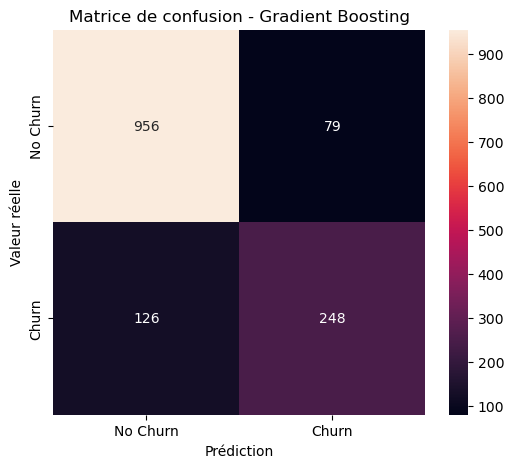


===== PERFORMANCES FINALES =====
Accuracy  : 0.8545
Precision : 0.7584
Recall    : 0.6631
F1-score  : 0.7076


In [11]:
# ÉTAPE 9 — ÉVALUATION FINALE DU MEILLEUR MODÈLE

# 1. Faire les prédictions finales

y_pred_final = best_model.predict(X_test)


# 2. Classification Report

from sklearn.metrics import classification_report

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Churn", "Churn"]
    )
)


# 3. Matrice de confusion

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_final
)

print("\n===== MATRICE DE CONFUSION =====")

print(cm)


# 4. Visualiser la matrice de confusion

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Gradient Boosting")

plt.show()


# 5. Afficher les métriques principales


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred_final
)

precision = precision_score(
    y_test,
    y_pred_final
)

recall = recall_score(
    y_test,
    y_pred_final
)

f1 = f1_score(
    y_test,
    y_pred_final
)


print("\n===== PERFORMANCES FINALES =====")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-score  :", round(f1, 4))

===== TOP 8 DES VARIABLES IMPORTANTES =====
               Variable  Importance
25             Contract    0.389325
8   Number_of_Referrals    0.115483
9        TenureinMonths    0.072653
28        MonthlyCharge    0.064511
1                   Age    0.058282
15         InternetType    0.039314
32         TotalRevenue    0.039165
6    NumberofDependents    0.034755


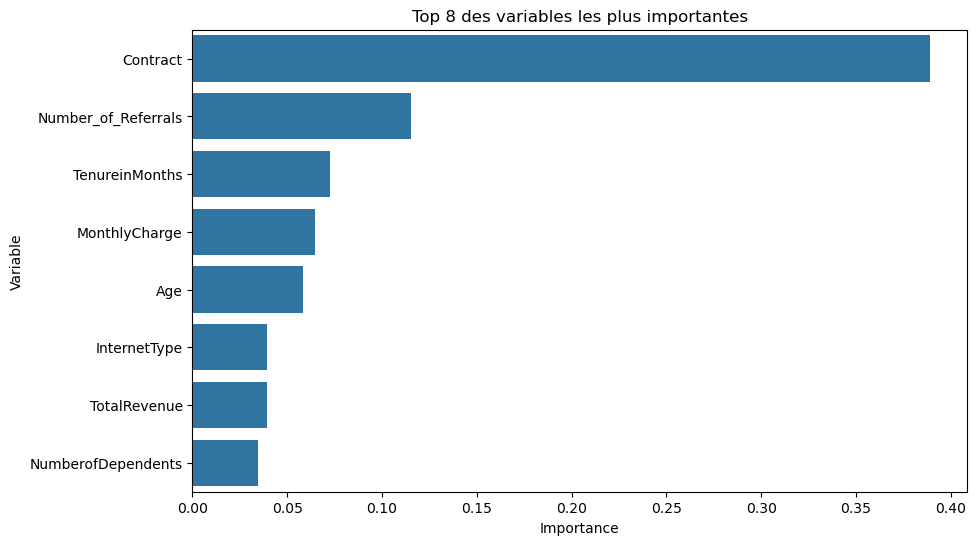

In [12]:
# ÉTAPE 10 — TOP 8 DES VARIABLES IMPORTANTES

# Récupérer l'importance des variables
importances = best_model.feature_importances_

# Créer le tableau
feature_importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": importances
})

# Trier de la plus importante à la moins importante
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Garder seulement les 8 premières
top_features = feature_importance.head(8)

# Afficher les 8 variables
print("===== TOP 8 DES VARIABLES IMPORTANTES =====")
print(top_features)


# GRAPHE

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Variable"
)

plt.title("Top 8 des variables les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.show()

In [13]:
import joblib

# Sauvegarder le meilleur modèle
joblib.dump(
    best_model,
    "gradient_boosting_churn.pkl"
)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [14]:
import joblib
import pickle

# ============================================================
# SAUVEGARDE DU SCALER
# ============================================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler sauvegardé avec succès ✅")


# ============================================================
# SAUVEGARDE DES FREQUENCES DES VARIABLES CATEGORIELLES
# ============================================================

frequency_encodings = {}

for col in categorical_features:
    
    frequencies = X_train[col].value_counts(normalize=True)
    
    frequency_encodings[col] = frequencies.to_dict()


with open("frequency_encodings.pkl", "wb") as f:
    pickle.dump(frequency_encodings, f)

print("Frequency encodings sauvegardés avec succès ✅")


# ============================================================
# SAUVEGARDE DES LISTES DE VARIABLES
# ============================================================

model_information = {
    "numeric_features": list(numeric_features),
    "categorical_features": list(categorical_features),
    "columns": list(X_train.columns)
}

with open("model_information.pkl", "wb") as f:
    pickle.dump(model_information, f)

print("Informations du modèle sauvegardées avec succès ✅")

Scaler sauvegardé avec succès ✅
Frequency encodings sauvegardés avec succès ✅
Informations du modèle sauvegardées avec succès ✅
